# Pause-based Metrics:

## Module 05: Lesson 01

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Critt-Kent/CRITT-Academy/blob/main/modules/05_Advanced_Analysis/01_Pause_based_Metrics.ipynb) | [This video linked here](https://vimeo.com/1201603642) explains how to use this code notebook in Google Colab 🤠

### What You Will Do In This Lesson

1. Install and import all necessary Python libraries
2. Load Segment and Keystroke Data tables (SG and KD tables) from the TPR-DB for a single study (a public study) and then read them into a DataFrame
3. Add pause-based metrics based on a different pause threshold than is available by default in the SG tables
4. Calculate additional, derived pause-based metrics such as pause-to-word ratio and average pause ratio

### First time working with a CRITT Academy code notebook?

If you haven't yet gone through the [CRITT Academy Module 01, Lesson 01, “Code Notebooks and the TPR_DB”](https://github.com/Critt-Kent/CRITT-Academy/blob/main/modules/01_Foundations/01_Notebooks_and_TPRDB.ipynb), you should do that first (this will help you understand Steps 1 through 3 much better).

## Step 1. Import all necessary Python libraries

- **NumPy**: `numpy` is used for scientific computing and data science
- **Pandas**: `pandas` is used for data manipulation, organization, and analysis
- **SciPy `stats`**: the `stats` module within `scipy` is used for statistical analysis and probability distributions
- **Matplotlib**: `matplotlib` is used for data visualization
- **Seaborn**: `seaborn` is used for nice-looking statistical graphics
- **tprdb-utilities**: `tprdb_utilities` is used for getting data remotely from the CRITT TPR-DB and then for reading data tables from a certain study (or studies) into a Pandas DataFrame.

In [10]:
# Environment Setup
import sys
from importlib.metadata import version, PackageNotFoundError
from packaging.version import Version

# Enforce a minimum Python version of 3.9+
if sys.version_info < (3, 9):
    raise RuntimeError(
        f"❌ Python 3.9 or higher is required. "
        f"You are currently running Python {sys.version_info.major}.{sys.version_info.minor}."
    )

REQUIRED = {
    "numpy": "2.4.0",
    "pandas": "3.0.0",
    "scipy": "1.17.0",
    "matplotlib": "3.10.0",
    "seaborn": "0.13.0",
    "tprdb-utilities": "0.7.0",
}

def _check_versions():
    outdated = []
    for pkg, min_ver in REQUIRED.items():
        try:
            installed = version(pkg)
            if Version(installed) < Version(min_ver):
                outdated.append(f"  {pkg}: installed {installed}, need >={min_ver}")
        except PackageNotFoundError:
            raise ImportError(f"{pkg} is not installed")
    return outdated

# Check if dependencies are missing and install them automatically
try:
    import numpy as np
    import pandas as pd
    import scipy.stats
    import matplotlib.pyplot as plt
    import seaborn as sns
    import tprdb_utilities

    outdated = _check_versions()
    if outdated:
        raise ImportError("Outdated packages:\n" + "\n".join(outdated))
    else:
        print("🤠 All core dependencies are already installed. You are ready to go! 🤘")
except ImportError:
    print("Missing dependencies detected. Installing required packages...")

    try:
        # The %pip magic ensures installation happens in the active Jupyter kernel
        %pip install "numpy>=2.4.0" "pandas>=3.0.0" "scipy>=1.17.0" "matplotlib>=3.10.0" "seaborn>=0.13.0" "tprdb-utilities>=0.7.0"

        print("\n🤠 Installation complete 🤘 If imports fail on the next cell, please restart the kernel.")
    except Exception as e:
        print(f"❌ An error occurred during installation: {e}")
        print("If using Google Colab, you may just have to restart your runtime now to use the newly installed packages.")

Missing dependencies detected. Installing required packages...
  Using cached numpy-2.5.1-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
  Using cached pandas-3.0.3-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (79 kB)
  Using cached scipy-1.18.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (62 kB)
  Using cached tprdb_utilities-0.5.0-py3-none-any.whl.metadata (9.0 kB)
Using cached numpy-2.5.1-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (16.7 MB)
Using cached pandas-3.0.3-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl (10.9 MB)
Using cached scipy-1.18.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (35.3 MB)
Using cached tprdb_utilities-0.5.0-py3-none-any.whl (19 kB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
ERROR: Could not install packages due to an OSError: [Errno 13] Permission denied: '/home/jupyte

### Set tpr-utility path on the CRITT server

In [15]:
# When working on the CRITT server: set the path to the tprdb_utilities directory:

import sys
TPR_utils = '/data/'
sys.path.append(f"{TPR_utils}/tprdb-utilities/src")  # point to the folder that CONTAINS the utilities package


In [16]:
# Now, import the libraries

try:
    # Standard Python library imports
    import numpy as np
    import pandas as pd
    import scipy.stats
    import matplotlib
    import matplotlib.pyplot as plt
    import seaborn as sns

    # TPR-DB utilities import
    from tprdb_utilities import fetch_TPRDB_tables, read_TPRDB_tables, recompute_pause_based_metrics

    print("✅ All imports successful!")

except ImportError as e:
    print(f"❌ An error occurred during imports: {e}")
    print("Please ensure all dependencies are installed and the kernel is restarted if necessary.")

✅ All imports successful!


## Step 2: Get Segments and Keystroke Data Tables and load them into DataFrames

### 🫵 Change code cell below

To get ready to run the `fetch_TPRDB_tables()` function, change the code cell below depending on your situation:
- **If *NOT* using Google Colab**:
    - Follow the **1st** set of directions to change the value of the `mothership_clone_location` variable
- **If you *are* using Google Colab**:
    - Follow the **2nd** set of directions to
        1. Comment out the code from the 1st set of directions
        2. Uncomment the code from the 2nd set of directions
        3. mount your Google Drive (unless you want it in a more specific location, you shouldn't need to change the value of the `mothership_clone_location` variable after uncommenting the code)

[Link to 📽️ Video on How to Comment Out and Uncomment Code](https://vimeo.com/1201588460)

#### ⚠️ If you are unsure what is going on here..

If you are confused about this step, it means you should go back and review [CRITT Academy Module 01, Lesson 01, “Code Notebooks and the TPR-DB”](https://github.com/Critt-Kent/CRITT-Academy/blob/main/modules/01_Foundations/01_Notebooks_and_TPRDB.ipynb).


In [17]:
# Commenting/Uncommenting Code: ⌘ + / (Mac) or Ctrl + / (Windows/Linux)

# 🫵 If NOT using Google Colab:
# 1) Change what's in the quotes below ("./") to point to where you want your mothership clone to be saved.
# 2) Then, run this code cell
mothership_clone_location = "~"


# No clone necessary whan working on the CRITT server: set to tprdb:
mothership_clone_location = "/data/critt/tprdb/"

# 🫵 If using Google Colab:
# 1) Comment out the above line of code
# 2) Uncomment the lines of code below
# 3) Then, run this code cell

# from google.colab import drive
# drive.mount('/content/drive')
# mothership_clone_location = "/content/drive/MyDrive/"

In [ ]:
# fetch data tables (notice we are using the `mothership_clone_location` variable we defined in the cell above)

fetch_TPRDB_tables(
    path=mothership_clone_location,
    studies=["BML12"],
    extensions=["ss", "sg", "kd"],
    public=True,
)

In [18]:
# read the Segments (SG) and Keystroke Data (KD) tables into a DataFrame

# BML12: (English) multiLing texts translated into Spanish
studies=["BML12"]

# read the Segments (SG)
SG = read_TPRDB_tables(
    path=f'{mothership_clone_location}', #/tprdb-mothership-clone',
    user='PUBLIC',
    studies=studies,
    extension="sg",
    verbose=1,
)

# read the Keystroke Data (KD)
KD = read_TPRDB_tables(
    path=f'{mothership_clone_location}', #/tprdb-mothership-clone',
    user='PUBLIC',
    studies=studies,
    extension="kd",
    verbose=1,
)

Reading: BML12	with 184 'sg' Tables
Total 'sg' data rows: 1229, columns: 39
Reading: BML12	with 184 'kd' Tables
Total 'kd' data rows: 93138, columns: 25


### Take a look at the pause-based metrics

In this next code cell, you'll take a look at *everything* in the Segments (SG) and Keystroke Data (KD) DataFrames, but take a *close look* at the Columns in the Segments DataFrame that start with these letters:

* **TB** – **T**yping **B**ursts (the number of stretches of typing used to translate/edit each segment)
* **TG** – **T**yping **G**ap (amount of time, in milliseconds, spent pausing between typing bursts)
* **TD** – **T**yping **D**uration (amount of time, in milliseconds, spent typing)

All of the preceding metrics depend on a certain **pause threshold**. We have to define how long someone has to **not be typing** in order for it to be considered a pause. There are three pause thresholds that come built in to the Segments (SG) tables:

* **1000**: 1000 milliseconds (nice and arbitrary 🤓)
* **KUI**: Keystroke Unit Interruption
* **PUB**: Production Unit Break

To read more about **KUI** and **PUB**, see the [TPR-DB Documentation: Features List](https://critt-kent.github.io/TPR-DB-documentation/analyze/features/).

In [19]:
# Check the two DataFrames' shapes and display the first few rows (with all columns visible) of each DataFrame
print(f"📊 The Segments DataFrame has {SG.shape[0]} rows and {SG.shape[1]} columns")

with pd.option_context("display.max_columns", None):
    display(SG.head())

print(f"📊 The Keystroke Data table has {KD.shape[0]} rows and {KD.shape[1]} columns")

with pd.option_context("display.max_columns", None):
    display(KD.head())

📊 The Segments DataFrame has 1229 rows and 39 columns


,Id,Study,Session,StudySession,SL,TL,Task,Text,Part,KUI,PUB,STseg,TTseg,LenS,LenT,TokS,TokT,Ins,Del,Dur,FixS,TrtS,FixT,TrtT,Nedit,PreGap,PostGap,TB1000,TG1000,TD1000,TB_KUI,TG_KUI,TD_KUI,TB_PUB,TG_PUB,TD_PUB,String,HTot,HTotN
0,1,BML12,P23_T1,BML12@P23_T1,en,es,T,1,P23,248,499,1,1,41,64,6,9,95,24,47500,5,455,30,4685,1,143671,16323,10,30562,17876,29,37841,10597,15,33639,14799,El_enfermero_asesino_recibe_cuatro_sentencias_...,1.5444,0.3117
1,2,BML12,P23_T1,BML12@P23_T1,en,es,T,1,P23,248,499,2,2,99,127,18,23,154,28,52141,16,2169,28,3555,1,1859,313,10,22720,29421,36,34406,17735,20,29016,23125,"El_enfermero_de_hospital_Colin_Norris_,_ha_sid...",0.8745,0.1765
2,3,BML12,P23_T1,BML12@P23_T1,en,es,T,1,P23,248,499,3,3,113,132,21,23,158,9,39953,28,3525,15,1898,2,69969,61063,6,11233,28720,34,23295,16658,12,15576,24377,"Norris_,_de_32_años_y_procedente_de_Glasgow_,_...",1.1939,0.2410
3,4,BML12,P23_T1,BML12@P23_T1,en,es,T,1,P23,248,499,4,4,81,100,16,19,113,14,31219,13,2912,6,584,1,1328,500,6,11531,19688,25,19732,11487,11,15140,16079,"Ayer_,_se_dictaminó_que_era_culpable_de_las_cu...",1.2368,0.2496
4,5,BML12,P23_T1,BML12@P23_T1,en,es,T,1,P23,248,499,5,5,65,91,14,17,91,1,13937,9,1619,9,987,1,500,4625,1,0,13937,10,3921,10016,3,1781,12156,Fue_sentenciado_a_cuatro_condenas_de_cadena_pe...,1.2930,0.2610


📊 The Keystroke Data table has 93138 rows and 25 columns


,Id,Study,Session,StudySession,SL,TL,Task,Text,Part,Time,Pause,Type,Cur,Char,Border,TTseg,TGid,TTid,STseg,SGid,STid,Phase,Strokes,Dur,Keys
0,1,BML12,P11_P5,BML12@P11_P5,en,es,P,5,P11,72844,72844,Ins,279,s,WW,3,47+48,47,3,43+44,43,D,1,1,---
1,2,BML12,P11_P5,BML12@P11_P5,en,es,P,5,P11,74516,1672,Ins,285,s,WD,3,47+48,48,3,43+44,43,D,1,1,---
2,3,BML12,P11_P5,BML12@P11_P5,en,es,P,5,P11,83218,8702,Del,322,variada,DW,4,56,56,4,52,52,D,1,1,---
3,4,BML12,P11_P5,BML12@P11_P5,en,es,P,5,P11,83219,1,Ins,322,v,WW,4,56,56,4,52,52,D,1,1,---
4,5,BML12,P11_P5,BML12@P11_P5,en,es,P,5,P11,83281,62,Ins,323,a,WW,4,56,56,4,52,52,D,1,1,---


## Step 3: Recompute the pause-based metrics based on a custom pause threshold

We can use a function called `recompute_pause_based_metrics()` (from the `transformer` module of the [`tprdb-utilities` python library](https://pypi.org/project/tprdb-utilities/)) to add new Typing Burst, Typing Gap, and Typing Duration metrics that are based on a custom pause threshold that we define to the Segments (SG) DataFrame.

In [ ]:
# view help documentation first
recompute_pause_based_metrics??

In [20]:
# add pause-based metrics using a pause threshold of 500 milliseconds
SG = recompute_pause_based_metrics(SG, KD, 5000)

In [28]:
# view the columns that were added to the Segments DataFrame
with pd.option_context("display.max_columns", None):
    display(SG.head())

,Id,Study,Session,StudySession,SL,TL,Task,Text,Part,KUI,PUB,STseg,TTseg,LenS,LenT,TokS,TokT,Ins,Del,Dur,FixS,TrtS,FixT,TrtT,Nedit,PreGap,PostGap,TB1000,TG1000,TD1000,TB_KUI,TG_KUI,TD_KUI,TB_PUB,TG_PUB,TD_PUB,String,HTot,HTotN,PWR1000,PWR_KUI,PWR_PUB,TB500,TG500,TD500
0,1,BML12,P23_T1,BML12@P23_T1,en,es,T,1,P23,248,499,1,1,41,64,6,9,95,24,47500,5,455,30,4685,1,143671,16323,10,30562,17876,29,37841,10597,15,33639,14799,El_enfermero_asesino_recibe_cuatro_sentencias_...,1.5444,0.3117,1.666667,4.833333,2.500000,15,33639,14799
1,2,BML12,P23_T1,BML12@P23_T1,en,es,T,1,P23,248,499,2,2,99,127,18,23,154,28,52141,16,2169,28,3555,1,1859,313,10,22720,29421,36,34406,17735,20,29016,23125,"El_enfermero_de_hospital_Colin_Norris_,_ha_sid...",0.8745,0.1765,0.555556,2.000000,1.111111,20,29016,23125
2,3,BML12,P23_T1,BML12@P23_T1,en,es,T,1,P23,248,499,3,3,113,132,21,23,158,9,39953,28,3525,15,1898,2,69969,61063,6,11233,28720,34,23295,16658,12,15576,24377,"Norris_,_de_32_años_y_procedente_de_Glasgow_,_...",1.1939,0.2410,0.285714,1.619048,0.571429,12,15576,24377
3,4,BML12,P23_T1,BML12@P23_T1,en,es,T,1,P23,248,499,4,4,81,100,16,19,113,14,31219,13,2912,6,584,1,1328,500,6,11531,19688,25,19732,11487,11,15140,16079,"Ayer_,_se_dictaminó_que_era_culpable_de_las_cu...",1.2368,0.2496,0.375000,1.562500,0.687500,11,15140,16079
4,5,BML12,P23_T1,BML12@P23_T1,en,es,T,1,P23,248,499,5,5,65,91,14,17,91,1,13937,9,1619,9,987,1,500,4625,1,0,13937,10,3921,10016,3,1781,12156,Fue_sentenciado_a_cuatro_condenas_de_cadena_pe...,1.2930,0.2610,0.071429,0.714286,0.214286,3,1781,12156


## Step 4: Calculate derivative pause-based metrics

Measures according to Isabel Lacruz and Gregory M. Shreve (2015).
To read more about pause-based metrics, see the [TPR-DB Documentation: Keystroke Pauses](https://critt-kent.github.io/TPR-DB-documentation/analyze/process/#keystroke-pauses).

- $\text{Pause Ratio (PR) } = \frac{\text{total pause time in segment}}{\text{total time in segment}}$
    
- $\text{Average Pause Ratio (APR)} = \frac{\text{average time per pause}}{\text{average time per words}}$

- $\text{Event-to-Word Ratio (EWR)} =\frac{\text{number of complete editing events}}{\text{number of words}}$
    
- $\text{Pause-to-word Ratio (PWR)} = \frac{\text{number of pauses in segment}}{\text{number of words in segment}}$


### Compute PWR values

In [21]:
# calculate different Pause-to-Word Ratios (PWR) using different pause thresholds and add them to the Segments (SG) DataFrame
# assuming that:
# -- the number of pauses is identical to the number of bursts, i.e., each burst is preceeded by a pause 
# -- we take "number of words" to be the number of ST words

SG["PWR1000"] = SG["TB1000"] / SG["TokS"]
SG["PWR_KUI"] = SG["TB_KUI"] / SG["TokS"]
SG["PWR_PUB"] = SG["TB_PUB"] / SG["TokS"]
SG["PWR5000"] = SG["TB5000"] / SG["TokS"]

# alternative assumptions are:
# -- there is also a pause following the last burst in a segment: add 1 to nominator:
# -- we take "number of words" to be the number of TT words

# SG["PWR1000_T"] = (SG["TB1000"] + 1) / SG["TokT"]
# SG["PWR_KUI_T"] = (SG["TB_KUI"] + 1) / SG["TokT"]
# SG["PWR_PUB_T"] = (SG["TB_PUB"] +1) / SG["TokT"]
# SG["PWR500_T"] = (SG["TB500"] +) / SG["TokST"]

# alternative assumptions are:
# -- average number of words in the ST and the TT side od the 

# SG["PWR1000_AV"] = 2 * SG["TB1000"] / (SG["TokS"] + SG["TokT"]) 
# SG["PWR_KUI_AV"] = 2 * SG["TB_KUI"] / (SG["TokS"] + SG["TokT"])
# SG["PWR_PUB_AV"] = 2 * SG["TB_PUB"] / (SG["TokS"] + SG["TokT"])
# SG["PWR500_AV"] = 2 * SG["TB500"] / (SG["TokS"] + SG["TokST"])

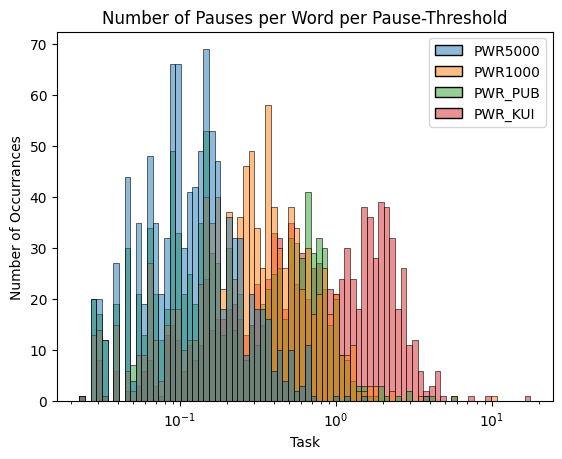

In [25]:
# 

ax = sns.histplot(data = SG[['PWR5000', 'PWR1000', 'PWR_PUB', 'PWR_KUI']], bins=80, log_scale=True)

# add labels
ax.set(ylabel='Number of Occurrances', xlabel='Task', title='Number of Pauses per Word per Pause-Threshold')
plt.show()

In [85]:
# print correlation between the PWR values:

SG[['PWR5000', 'PWR1000', 'PWR_PUB', 'PWR_KUI']].corr()


,PWR5000,PWR1000,PWR_PUB,PWR_KUI
PWR5000,1.000000,0.912689,0.764105,0.766467
PWR1000,0.912689,1.000000,0.872832,0.893933
PWR_PUB,0.764105,0.872832,1.000000,0.938901
PWR_KUI,0.766467,0.893933,0.938901,1.000000


### Compute APR values

In [ ]:
# APR: average time per pause / average time per word
#  average time per word: TypingDuration / number of words: SG["TDx"] / SG["TokT"]
#  average time per pause: TypingGap / Typing bursts + 1 : SG2["TGx"] / SG["TBx"] +1
#  -- there is one more typing pause than typing bursts 

SG["APR5000"] = (SG["TG5000"] * SG["TokT"]) / (1+ SG["TB5000"] * SG["TD5000"] )
SG["APR1000"] = (SG["TG1000"] * SG["TokT"]) / (1+ SG["TB1000"] * SG["TD1000"])
SG["APR_PUB"] = (SG["TG_PUB"] * SG["TokT"]) / (1+ SG["TB_PUB"] * SG["TD_PUB"])
SG["APR_KUI"] = (SG["TG_KUI"] * SG["TokT"]) / (1+ SG["TB_KUI"] * SG["TD_KUI"])

# alternative assumptions:
# --- take into account the PreGap, the first pause in the segment

# SG["APR5000_PG"] = (SG["PreGap"] + SG["TG5000"] * SG["TokT"]) / (1+ SG["TB5000"] * SG["TD5000"] )
# SG["APR1000_PG"] = (SG["PreGap"] + SG["TG1000"] * SG["TokT"]) / (1+ SG["TB1000"] * SG["TD1000"])

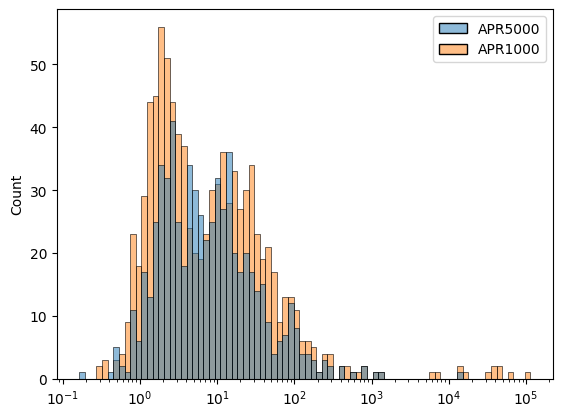

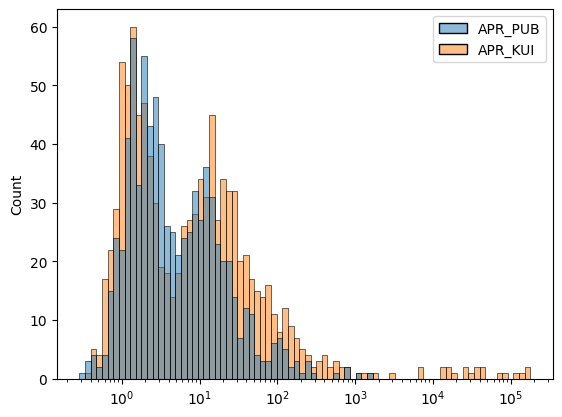

,Id,Study,Session,StudySession,SL,TL,Task,Text,Part,KUI,PUB,STseg,TTseg,LenS,LenT,TokS,TokT,Ins,Del,Dur,FixS,TrtS,FixT,TrtT,Nedit,PreGap,PostGap,TB1000,TG1000,TD1000,TB_KUI,TG_KUI,TD_KUI,TB_PUB,TG_PUB,TD_PUB,String,HTot,HTotN,TB5000,TG5000,TD5000,PWR1000,PWR_KUI,PWR_PUB,PWR5000,APR5000,APR1000,APR_PUB,APR_KUI,APR5000_PG,APR1000_PG
0,1,BML12,P23_T1,BML12@P23_T1,en,es,T,1,P23,248,499,1,1,41,64,6,9,95,24,47500,5,455,30,4685,1,143671,16323,10,30562,17876,29,37841,10597,15,33639,14799,El_enfermero_asesino_recibe_cuatro_sentencias_...,1.5444,0.3117,4,15156,33282,1.666667,4.833333,2.500000,0.666667,1.024600,1.538691,1.363829,1.108212,2.103787,2.342396
1,2,BML12,P23_T1,BML12@P23_T1,en,es,T,1,P23,248,499,2,2,99,127,18,23,154,28,52141,16,2169,28,3555,1,1859,313,10,22720,29421,36,34406,17735,20,29016,23125,"El_enfermero_de_hospital_Colin_Norris_,_ha_sid...",0.8745,0.1765,2,9391,42750,0.555556,2.000000,1.111111,0.111111,2.526204,1.776140,1.442955,1.239446,2.547947,1.782459
2,3,BML12,P23_T1,BML12@P23_T1,en,es,T,1,P23,248,499,3,3,113,132,21,23,158,9,39953,28,3525,15,1898,2,69969,61063,6,11233,28720,34,23295,16658,12,15576,24377,"Norris_,_de_32_años_y_procedente_de_Glasgow_,_...",1.1939,0.2410,3,5734,34219,0.285714,1.619048,0.571429,0.142857,1.284673,1.499289,1.224675,0.945993,1.966247,1.905328
3,4,BML12,P23_T1,BML12@P23_T1,en,es,T,1,P23,248,499,4,4,81,100,16,19,113,14,31219,13,2912,6,584,1,1328,500,6,11531,19688,25,19732,11487,11,15140,16079,"Ayer_,_se_dictaminó_que_era_culpable_de_las_cu...",1.2368,0.2496,1,0,31219,0.375000,1.562500,0.687500,0.062500,0.000000,1.854659,1.626392,1.305499,0.042537,1.865901
4,5,BML12,P23_T1,BML12@P23_T1,en,es,T,1,P23,248,499,5,5,65,91,14,17,91,1,13937,9,1619,9,987,1,500,4625,1,0,13937,10,3921,10016,3,1781,12156,Fue_sentenciado_a_cuatro_condenas_de_cadena_pe...,1.2930,0.2610,1,0,13937,0.071429,0.714286,0.214286,0.071429,0.000000,0.000000,0.830212,0.665499,0.035873,0.035873


In [ ]:
# plot the APR values in a histplot

sns.histplot(data = SG[['APR5000', 'APR1000']], bins=80, log_scale=True)
plt.show()
sns.histplot(data = SG[['APR_PUB', 'APR_KUI']], bins=80, log_scale=True)
plt.show()

with pd.option_context("display.max_columns", None):
    display(SG.head())

In [87]:
# print correlation between the APR values

SG[['APR5000', 'APR1000', 'APR_PUB', 'APR_KUI']].corr()


,APR5000,APR1000,APR_PUB,APR_KUI
APR5000,1.000000,0.086279,0.153289,0.038013
APR1000,0.086279,1.000000,0.004553,0.471807
APR_PUB,0.153289,0.004553,1.000000,-0.005336
APR_KUI,0.038013,0.471807,-0.005336,1.000000
